In [1]:
%%html
<style type="text/css">
  span.ecb { background: yellow; }
</style>
<span class="ecb">Grading comments will be in yellow</span>

In [51]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy

# ATMO 5331 - Homework #4
### Spring 2026, Due 21 Apr, 2026, 2 pm (before class).

This is a checkpoint assignment that will be **ungraded** (25\% credit on the combined HW4, 5 for turning in a completed assignment). There is not really any mystery about the right answer here, since you are reproducing a known result from a paper.

For homework 4 and 5, you my work individually or with a group of up to two other class members. If you work together, please say who you worked with in the assignment and only turn in one assignment on GitHub.

When working these problems, you will need to code up equations for and make plots of various electrostatic quantities. Turn in a Jupyter notebook with your figures and which I can run to reproduce your results. Label your axes like a professional.

Please also enter your derivations into the notebook using $\LaTeX$. Provide any needed discussion as commentary in the notebook in a Markdown cell.

### 1. 

Review [Krehbiel et al. (1979)](http://dx.doi.org/10.1029/JC084iC05p02432), which I've [previously shared](http://www.atmo.ttu.edu/bruning/5322/Papers-20221020/). Eqns. 2, 3, and 4 include a range dependence for the field changes produced by monopole and dipole charge motions. Beginning with the Shao (2016, eq. 17) formulation for the elecstrostatic change, derive these simplified formulae.

### 2.

Write a function that takes a charge and its position, and calculates the monopole change. 

Also write a function that calculates the point dipole field change given a charge magnitude, position, and its travel distance.

In [3]:
epsilon0 = 8.854e-12 #F/m

In [102]:
def monopole_deltaE(Q, Ri):

    '''
    Q = point charge
    Ri = [(x-xi)^2 + ...]^3/2; the point location - the obs location
    
    '''
    z= Ri[2]
    Ri_magnitude = np.sqrt(Ri[0]**2 + Ri[1]**2 + Ri[2]**2)
    a = 1/(4*np.pi*epsilon0)
    
    deltaE = (a) * (2*Q*z / (Ri_magnitude)**(3))

    return deltaE

In [103]:
def pointdiploe_deltaE(Q, Ri, deltaR, z):

    '''
    deltaR = travel distance

    '''
    Ri_magnitude = np.sqrt(Ri[0]**2 + Ri[1]**2 + Ri[2]**2)
    deltaR_mag = np.sqrt(deltaR[0]**2 + deltaR[1]**2 + deltaR[2]**2)
    
    p = Q * deltaR

    a = 1/(4*np.pi*epsilon0)

    pz = Q * deltaR[2]

    deltaE = a * ( (2*pz/(Ri_magnitude**3)) - ( (6*z/(Ri_magnitude**5)) * np.dot(Ri.T, p) ) )

    return deltaE

### 3.

Create a pandas dataframe of x, y, and z (set uniformly to 1830 m MSL) positions for the stations in Fig. 1.

Also create a CSV file for the locations, magnitudes and charge motions inferred by the authors for the strokes associated with flash 9 (Fig. 9, 10). See Table 1 and Fig. 10 for charge amounts and motions. Columns should be `q, qx, qy, qz, drx, dry, drz, change_type` with the `dr` components set to `np.nan` for the monopole. See section 3 for why this is the case. The change type should be one of `monopole`, `pointdipole`.

Read in the charge data with `pandas`, and separate the monopole and dipole strokes using a `groupby` on the `change_type` column, and display those two data tables.

In [6]:
station_positions = {'Name': ['windmill', 'abandonedhouse', 'strozzi', 'kelly', 'watercanyon'],
                     'x': [2000, 0, 0, 3000, 4500],
                     'y': [9000, 5000, 0, 500, -7000],
                     'z': [1830] * 5
                    }

station_positions_df = pd.DataFrame(data=station_positions)

In [7]:
station_positions_df

,Name,x,y,z
0,windmill,2000,9000,1830
1,abandonedhouse,0,5000,1830
2,strozzi,0,0,1830
3,kelly,3000,500,1830
4,watercanyon,4500,-7000,1830


In [8]:
strokes_mono = {'q':[5.3, 1.0, 2.8, 2.3, 6.7, 3.7, 2.2, 6.0],
           'qx':[1000, 0, 0, 0, -1000, 1500, -1000, -1500],
           'qy':[7000, 7000, 6000, 5000, 5000, 2000, 1500, 500],
           'qz':[6000, 5500, 5000, 4500, 5000, 4500, 5000, 5000],
           'drx':[np.nan] * 8,
           'dry':[np.nan] * 8,
           'drz':[np.nan] * 8,
           'change_type':['monopole'] * 8
               }
           
strokes_di = {'q':[4.0],
           'qx':[(500-1000)/2],
           'qy':[(6500+3000)/2],
           'qz':[(5500+1500)/2],
           'drx':[(500-1000)],
           'dry':[(6500+3000)],
           'drz':[(5500+1500)],
           'change_type':['pointdipole']
               }

strokes_mono_df = pd.DataFrame(data=strokes_mono)
strokes_di_df = pd.DataFrame(data=strokes_di)

strokes_df = pd.concat([strokes_mono_df, strokes_di_df])
# strokes_di = {'q':[3.9, 4.1],
#            'qx':[5.5, 5.5],
#            'qy':[5.5, 5.5],
#            'qz':[5.5, 5.5],
#            'drx':[5.5+0.16, 5.5-0.03],
#            'dry':[5.5+0.29, 5.5-0.03],
#            'drz':[5.5+0.29, 5.5-0.06],
#            'change_type':['pointdipole']
#                }

In [9]:
strokes_df

,q,qx,qy,qz,drx,dry,drz,change_type
0,5.3,1000.0,7000.0,6000.0,NaN,NaN,NaN,monopole
1,1.0,0.0,7000.0,5500.0,NaN,NaN,NaN,monopole
2,2.8,0.0,6000.0,5000.0,NaN,NaN,NaN,monopole
3,2.3,0.0,5000.0,4500.0,NaN,NaN,NaN,monopole
4,6.7,-1000.0,5000.0,5000.0,NaN,NaN,NaN,monopole
5,3.7,1500.0,2000.0,4500.0,NaN,NaN,NaN,monopole
6,2.2,-1000.0,1500.0,5000.0,NaN,NaN,NaN,monopole
7,6.0,-1500.0,500.0,5000.0,NaN,NaN,NaN,monopole
0,4.0,-250.0,4750.0,3500.0,-500.0,9500.0,7000.0,pointdipole


### 4.

Use your functions to calculate the field changes associated with the strokes in flash 9. Make a plot (which will only partially reproduce the data at each station) and compare your calculated results to Fig. 9. What differences do you observe, and are the differences consistent with the $\Chi^2$ values in K79 Table 1?

In [104]:
R_dict_mono = {}

for qname, lname, Rname in zip(['qx', 'qy', 'qz'], ['x', 'y', 'z'], ['Rx', 'Ry', 'Rz']):
    strokes = strokes_mono_df[qname].to_numpy()[:, None]      # shape (8, 1), to_numpy makes the pandas table to a numpy array
    stations = station_positions_df[lname].to_numpy()[None, :]  # shape (1, 5)
    
    R = strokes - stations   # shape (8, 5)
    
    R_dict_mono[Rname] = R # now each row has 5 columns, one for each station location, and 8 rows, one for each flash

In [105]:
R_dict_mono

{'Rx': array([[-1000,  1000,  1000, -2000, -3500],
        [-2000,     0,     0, -3000, -4500],
        [-2000,     0,     0, -3000, -4500],
        [-2000,     0,     0, -3000, -4500],
        [-3000, -1000, -1000, -4000, -5500],
        [ -500,  1500,  1500, -1500, -3000],
        [-3000, -1000, -1000, -4000, -5500],
        [-3500, -1500, -1500, -4500, -6000]]),
 'Ry': array([[-2000,  2000,  7000,  6500, 14000],
        [-2000,  2000,  7000,  6500, 14000],
        [-3000,  1000,  6000,  5500, 13000],
        [-4000,     0,  5000,  4500, 12000],
        [-4000,     0,  5000,  4500, 12000],
        [-7000, -3000,  2000,  1500,  9000],
        [-7500, -3500,  1500,  1000,  8500],
        [-8500, -4500,   500,     0,  7500]]),
 'Rz': array([[4170, 4170, 4170, 4170, 4170],
        [3670, 3670, 3670, 3670, 3670],
        [3170, 3170, 3170, 3170, 3170],
        [2670, 2670, 2670, 2670, 2670],
        [3170, 3170, 3170, 3170, 3170],
        [2670, 2670, 2670, 2670, 2670],
        [3170, 317

In [106]:
Ri_mono = np.array([R_dict_mono['Rx'], R_dict_mono['Ry'], R_dict_mono['Rz']])

In [107]:
Ri_mono

array([[[-1000,  1000,  1000, -2000, -3500],
        [-2000,     0,     0, -3000, -4500],
        [-2000,     0,     0, -3000, -4500],
        [-2000,     0,     0, -3000, -4500],
        [-3000, -1000, -1000, -4000, -5500],
        [ -500,  1500,  1500, -1500, -3000],
        [-3000, -1000, -1000, -4000, -5500],
        [-3500, -1500, -1500, -4500, -6000]],

       [[-2000,  2000,  7000,  6500, 14000],
        [-2000,  2000,  7000,  6500, 14000],
        [-3000,  1000,  6000,  5500, 13000],
        [-4000,     0,  5000,  4500, 12000],
        [-4000,     0,  5000,  4500, 12000],
        [-7000, -3000,  2000,  1500,  9000],
        [-7500, -3500,  1500,  1000,  8500],
        [-8500, -4500,   500,     0,  7500]],

       [[ 4170,  4170,  4170,  4170,  4170],
        [ 3670,  3670,  3670,  3670,  3670],
        [ 3170,  3170,  3170,  3170,  3170],
        [ 2670,  2670,  2670,  2670,  2670],
        [ 3170,  3170,  3170,  3170,  3170],
        [ 2670,  2670,  2670,  2670,  2670],
      

In [108]:
Ri_mono.shape

(3, 8, 5)

In [109]:
Ri_mono_vector = np.sqrt(R_dict_mono['Rx']**2 + R_dict_mono['Ry']**2 + R_dict_mono['Rz']**2)

In [110]:
Ri_mono_vector

array([[ 4731.69102964,  4731.69102964,  8209.07424744,  7977.39932559,
        15021.28156983],
       [ 4633.45443487,  4179.58131874,  7903.72696897,  8044.80577764,
        15156.48046217],
       [ 4800.92699382,  3323.98856797,  6785.93398141,  7021.31754018,
        14117.3262341 ],
       [ 5208.54106252,  2670.        ,  5668.23605719,  6031.49235264,
        13091.17641773],
       [ 5920.21114488,  3323.98856797,  6004.07361714,  6804.32950407,
        13575.67309565],
       [ 7508.58841594,  4287.06193097,  3657.71786774,  3410.11730004,
         9855.39953528],
       [ 8677.49387784,  4826.89341088,  3646.76569031,  5200.85569882,
        10608.90663546],
       [ 9723.62586693,  5705.16432717,  3542.44266009,  5504.44365944,
        10114.29186844]])

In [111]:
R_dict_di = {}

for qname, lname, Rname, dRname in zip(['qx', 'qy', 'qz'], ['x', 'y', 'z'], ['Rx', 'Ry', 'Rz'], ['dRx', 'dRy', 'dRz']):
    dR = strokes_di[qname]#.to_numpy()[None, :] # center of dR
    #dR_np = dR  # shape (8, 1), to_numpy makes the pandas table to a numpy array
    stations = station_positions_df[lname].to_numpy()[None, :]  # shape (1, 5)
    
    R = dR - stations   # shape (8, 5)
    
    R_dict_di[Rname] = R # now each row has 5 columns, one for each station location, and 8 rows, one for each flash

In [112]:
Ri_di = np.sqrt(R_dict_di['Rx']**2 + R_dict_di['Ry']**2 + R_dict_di['Rz']**2)

In [113]:
R_dipole = np.array([R_dict_di['Rx'], R_dict_di['Ry'], R_dict_di['Rz']])
dR_dipole = np.array([strokes_di['drx'], strokes_di['dry'], strokes_di['drz']])

In [114]:
R_dipole

array([[[-2250.,  -250.,  -250., -3250., -4750.]],

       [[-4250.,  -250.,  4750.,  4250., 11750.]],

       [[ 1670.,  1670.,  1670.,  1670.,  1670.]]])

In [115]:
dR_dipole

array([[-500],
       [9500],
       [7000]])

In [116]:
R_dipole.shape

(3, 1, 5)

In [117]:
dR_dipole.shape

(3, 1)

In [118]:
deltaR = 5.5

In [119]:
deltaR_z = dR_dipole[2] # retreived from looking at figure 9

In [120]:
strokes_mono_df['q'].to_numpy()[:,None]

array([[5.3],
       [1. ],
       [2.8],
       [2.3],
       [6.7],
       [3.7],
       [2.2],
       [6. ]])

In [121]:
strokes_mono_df['qz'].to_numpy()[:,None].shape

(8, 1)

In [122]:
Q = 4.0

In [123]:
mono_deltaE = monopole_deltaE(strokes_mono_df['q'].to_numpy()[:,None], Ri_mono)

di_deltaE = pointdiploe_deltaE(Q, R_dipole, dR_dipole, strokes_di_df['qz'].to_numpy()[:,None])

In [124]:
mono_deltaE

array([[ 3750.10479205,  3750.10479205,   718.14143887,   782.54359688,
          117.21186543],
       [  663.18086765,   903.54198993,   133.61366916,   126.70681886,
           18.94748562],
       [ 1441.85836727,  4344.29534755,   510.58613459,   460.93752337,
           56.707507  ],
       [  781.21654841,  5799.43823237,   606.14416127,   503.08963159,
           49.20210517],
       [ 1839.93758283, 10395.27815306,  1763.91093759,  1211.87735282,
          152.59157801],
       [  419.48718902,  2253.79456514,  3628.79962485,  4478.01604705,
          185.51152432],
       [  191.85786584,  1114.70367001,  2584.87160881,   891.12400864,
          104.99066219],
       [  371.88306851,  1841.13931788,  7690.99694517,  2049.98571133,
          330.43396435]])

In [154]:
di_deltaE

array([[[ 9.90202852e+03,  1.53675129e+06,  1.03189854e+04,
          6.62049226e+03,  3.01889731e+02]],

       [[ 1.73056809e+03, -3.90529619e+05,  1.73965610e+03,
          1.57007819e+03,  2.20060374e+02]],

       [[-8.75982031e+03, -2.86474160e+06, -9.27434770e+03,
         -4.91356150e+03,  1.15009172e+02]],

       [[-8.04205689e+03, -2.69545341e+06, -8.52075797e+03,
         -4.46994405e+03,  1.22196885e+02]],

       [[-2.39432772e+04, -6.44583789e+06, -2.52156690e+04,
         -1.42977768e+04, -3.70386211e+01]]])

In [125]:
mono_deltaE.shape

(8, 5)

In [126]:
di_deltaE.shape

(5, 1, 5)

Text(0.5, 1.0, 'Monopole dE for Stations')

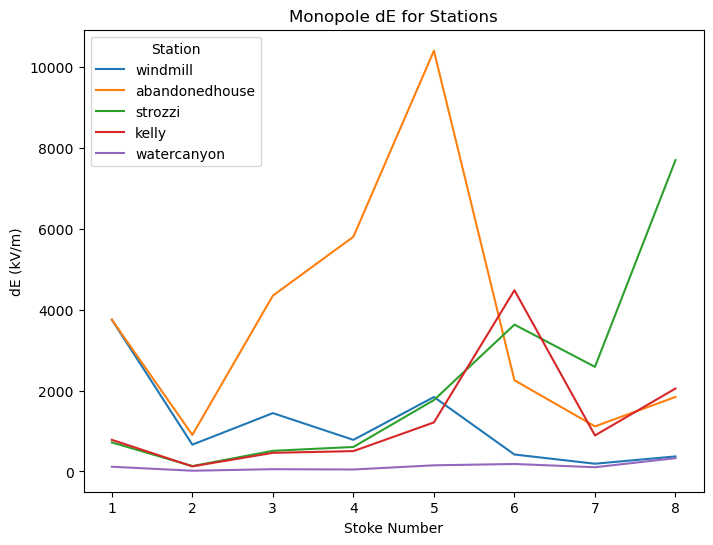

In [129]:
plt.figure(figsize=(8,6))
t = np.arange(1,9)

for i, place in zip(range(5), station_positions_df['Name']):
    plt.plot(t, mono_deltaE[:, i], label=place)

plt.legend(title='Station')
plt.xlabel('Stoke Number')
plt.ylabel('dE (kV/m)')
plt.title('Monopole dE for Stations')

Large jump at 1 and 5, as seen in Fig. 9

### 5. 

Implement nonlinear least squares retrieval of location and charge magnitude using `scipy.optimize.leastsq`. 
Using the electric field change data you calculated, retrieve the charge and location of strokes 5 and 6a from K79 Flash 9.

Describe how you chose the initial guess for the solution location and charge magnitude.

Since you generated the $\Delta E$ data, you should find an exact match for both strokes. Do you?

**`leastsq` by example**

An example of how to use `leastsq` is in [Chmielewski and Bruning (2016)](http://dx.doi.org/10.1002/2016jd025159), which is also [available in a repository of some papers on my website](http://www.atmo.ttu.edu/bruning/5322/Papers-20221020/). This paper studies errors in time-of-arrival (TOA) retrievals. The code associated with the paper [is available](https://github.com/vbalderdash/LMAsimulation).

There is a main simulation notebook that calls a `black_box` function that drives the calculations. The `black_box` funciton is located in `simulation_functions.py`, which also contains a variety of supporting functions to do various steps of the analysis. Especially relevant are `gen_retrieval_math` and `residuals`.
 
The "full" simulation notebook creates an ensemble of trial emissions at some known location (or more than one location), with a distribution of timing errors. Each trial emission is propagated to each station, and then the ensemble of receptions is run back through a non-linear least-squares solver to retrieve the original emission location. This _Monte Carlo simulation_ approach gives us a known truth, control over errors, and simulates the reception and processing of the data by each station. (We also choose to avoid having to figure out which trigger goes with which emission, since we control the emissions. Practically speaking, this step turns out to be among the most expensive parts of finding a solution, and is done with a naive, brute force approach!)

In [130]:
flash_5 = strokes_mono_df.iloc[4][:-4]
flash_6 = strokes_mono_df.iloc[5][:-4]

In [131]:
flash_5

q       6.7
qx    -1000
qy     5000
qz     5000
Name: 4, dtype: object

In [132]:
flash_6

q      3.7
qx    1500
qy    2000
qz    4500
Name: 5, dtype: object

In [133]:
Ri_mono[:,4]

array([[-3000, -1000, -1000, -4000, -5500],
       [-4000,     0,  5000,  4500, 12000],
       [ 3170,  3170,  3170,  3170,  3170]])

In [149]:
#f5_guess = [6.7, -1000, 5000, 5000]
f5_guess = [5, -3000, 4000, 4000]
f6_guess = [3.7, 1500, 2000, 4500]

In [150]:
strokes_mono_df.iloc[4]['qx']

np.int64(-1000)

In [151]:
def obs_vs_sim_E(guess, stroke):
    
    Q, x, y, z = guess

    strokesx = strokes_mono_df.iloc[stroke]['qx']
    strokesy = strokes_mono_df.iloc[stroke]['qy']
    strokesz = strokes_mono_df.iloc[stroke]['qz']

    Ri = [strokesx - x, strokesy - y, strokesz - z]
    
    dE = monopole_deltaE(Q, Ri)

    dE_obs = mono_deltaE[stroke]

    diff_E = dE_obs - dE

    return diff_E

In [152]:
f5_leastsq = scipy.optimize.leastsq(obs_vs_sim_E, f5_guess, args=(4,))

In [153]:
f5_leastsq

(array([ -993.93383038, 22687.59209162,  6821.74573102, 75315.85500727]), 1)

### Next: HW5.

In HW5 you will use the retrieval code you wrote, to study the sensitivity of the retrievals to measurement error.

If you want to get ahead, you can certainly start working on the retrieval of the original sources right away. That will be the second half of this project. 

Since we will not really be using timing information to retireve our source process, we'll need to replace the timing errors in the Monte Carlo simulation with a matrix of charge magnitude and location errors.